In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:
print('hello')

hello


In [3]:
df = pd.read_csv("economy-and-growth.csv")

growth_col = "average_value_GDP growth (annual %)"

In [4]:
# ── Country groups ─────────────────────────────────────────────────────────────
high_income = ["United States", "United Kingdom", "Germany", "Japan",
               "France", "Canada", "Australia", "Italy"]

developing  = ["China", "India", "Brazil", "Nigeria", "Indonesia",
               "Bangladesh", "Ethiopia", "Vietnam", "Mexico", "Pakistan"]

# ── Filter & clean ─────────────────────────────────────────────────────────────
df_filtered = df[df["Country Name"].isin(high_income + developing)].copy()
df_filtered = df_filtered[["Country Name", "Year", growth_col]].dropna()
df_filtered["Year"] = pd.to_numeric(df_filtered["Year"], errors="coerce")
df_filtered = df_filtered.dropna(subset=["Year"])
df_filtered["Year"] = df_filtered["Year"].astype(int)

df_filtered["Group"] = df_filtered["Country Name"].apply(
    lambda x: "High-Income" if x in high_income else "Developing"
)

bins   = [1959, 1969, 1979, 1989, 1999, 2009, 2020]
labels = ["1960s", "1970s", "1980s", "1990s", "2000s", "2010s"]
df_filtered["Decade"] = pd.cut(df_filtered["Year"], bins=bins, labels=labels)
df_filtered = df_filtered.dropna(subset=["Decade"])

# ── Aggregate: mean growth per group per decade ────────────────────────────────
agg = (df_filtered
       .groupby(["Decade", "Group"])[growth_col]
       .mean()
       .unstack("Group"))

agg["Gap"] = agg["Developing"] - agg["High-Income"]

print(agg.round(2))

Group   Developing  High-Income   Gap
Decade                               
1960s         4.64         5.71 -1.07
1970s         5.72         3.54  2.18
1980s         4.32         2.90  1.41
1990s         4.65         2.33  2.33
2000s         5.91         1.67  4.24
2010s         4.85         1.11  3.74


/var/folders/hq/_tkslfmj2vld7n2rfp92x0wr0000gn/T/ipykernel_29922/3536340176.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Decade", "Group"])[growth_col]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/viz2_growth_gap.png'

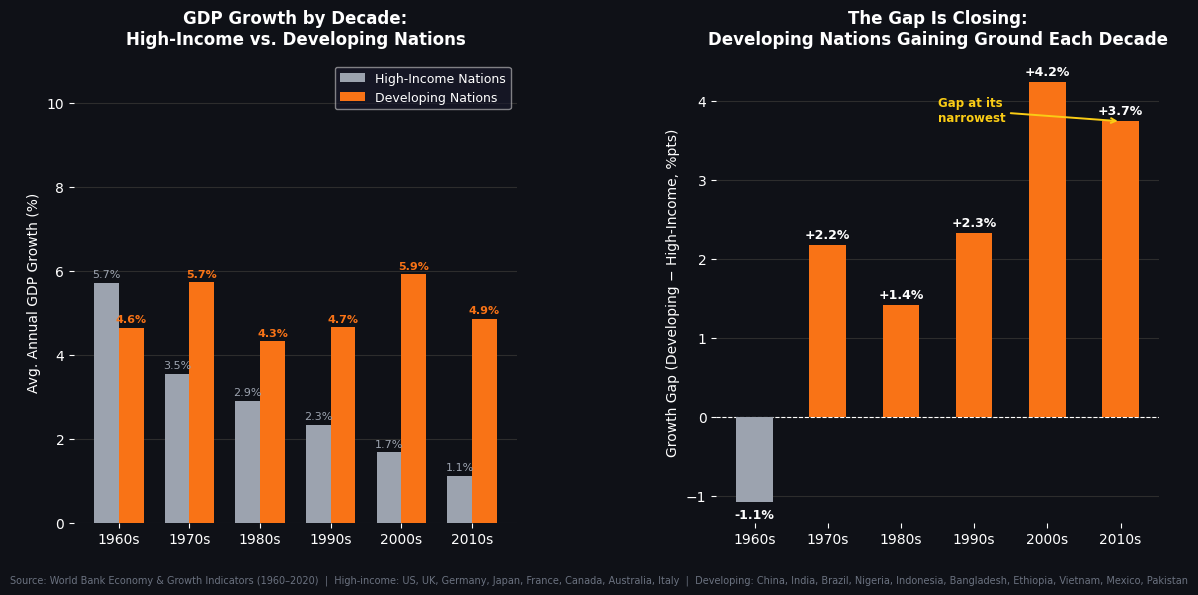

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         facecolor="#0f1117", gridspec_kw={"wspace": 0.45})
 
decades = agg.index.tolist()
x       = np.arange(len(decades))
bar_w   = 0.35
 
# ── LEFT PANEL: Side-by-side bars ──────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0f1117")
 
bars_hi  = ax1.bar(x - bar_w/2, agg["High-Income"], bar_w,
                   color="#9ca3af", label="High-Income Nations", zorder=3)
bars_dev = ax1.bar(x + bar_w/2, agg["Developing"],  bar_w,
                   color="#f97316", label="Developing Nations",  zorder=3)
 
# value labels on bars
for bar in bars_hi:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             color="#9ca3af", fontsize=8)
for bar in bars_dev:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             color="#f97316", fontsize=8, fontweight="bold")
 
ax1.set_xticks(x)
ax1.set_xticklabels(decades, color="white", fontsize=10)
ax1.set_ylabel("Avg. Annual GDP Growth (%)", color="white", fontsize=10)
ax1.set_ylim(0, 11)
ax1.tick_params(colors="white")
ax1.spines[["top","right","left","bottom"]].set_visible(False)
ax1.yaxis.grid(True, color="#2d2d2d", linewidth=0.8, zorder=0)
ax1.set_title("GDP Growth by Decade:\nHigh-Income vs. Developing Nations",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax1.legend(facecolor="#1a1a2e", labelcolor="white", framealpha=0.6,
           fontsize=9, loc="upper right")
 
# ── RIGHT PANEL: Gap bar (Developing − High-Income) ───────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0f1117")
 
gap_colors = ["#f97316" if g > 0 else "#9ca3af" for g in agg["Gap"]]
gap_bars   = ax2.bar(x, agg["Gap"], 0.5, color=gap_colors, zorder=3)
 
for bar, val in zip(gap_bars, agg["Gap"]):
    ypos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.25
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f"+{val:.1f}%" if val > 0 else f"{val:.1f}%",
             ha="center", va="bottom", color="white",
             fontsize=9, fontweight="bold")
 
# Annotate the last bar to highlight the closing gap
last_idx = len(decades) - 1
ax2.annotate("Gap at its\nnarrowest",
             xy=(last_idx, agg["Gap"].iloc[-1]),
             xytext=(last_idx - 2.5, agg["Gap"].iloc[-1]),
             color="#facc15", fontsize=8.5, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#facc15", lw=1.4))
 
ax2.axhline(0, color="#ffffff", linewidth=0.8, linestyle="--", zorder=2)
ax2.set_xticks(x)
ax2.set_xticklabels(decades, color="white", fontsize=10)
ax2.set_ylabel("Growth Gap (Developing − High-Income, %pts)",
               color="white", fontsize=10)
ax2.tick_params(colors="white")
ax2.spines[["top","right","left","bottom"]].set_visible(False)
ax2.yaxis.grid(True, color="#2d2d2d", linewidth=0.8, zorder=0)
ax2.set_title("The Gap Is Closing:\nDeveloping Nations Gaining Ground Each Decade",
              color="white", fontsize=12, fontweight="bold", pad=12)
 
# ── Source note ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         "Source: World Bank Economy & Growth Indicators (1960–2020)  |  "
         "High-income: US, UK, Germany, Japan, France, Canada, Australia, Italy  |  "
         "Developing: China, India, Brazil, Nigeria, Indonesia, Bangladesh, Ethiopia, Vietnam, Mexico, Pakistan",
         ha="center", color="#6b7280", fontsize=7)
 
plt.savefig("/mnt/user-data/outputs/viz2_growth_gap.png",
            dpi=180, bbox_inches="tight", facecolor="#0f1117")
print("Saved → viz2_growth_gap.png")
plt.show()
